In [90]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.distributions import Categorical
import torch.nn.functional as F
from stable_baselines3.common.vec_env import VecEnv, DummyVecEnv
from stable_baselines3 import PPO
import logging
import matplotlib.pyplot as plt

In [91]:
# Configure logging
logging.basicConfig(filename='./training.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [92]:
class StockTradingEnv(gym.Env):
    def __init__(self, df):
        super(StockTradingEnv, self).__init__()
        self.df = df
        self.current_step = 0
        self.action_space = spaces.Discrete(3)  # 0: Hold, 1: Buy, 2: Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(df.columns),), dtype=np.float32)
        self.initial_balance = 10000000  # 1000만원
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        self.seed()

    def seed(self, seed=None):
        self.np_random = np.random.default_rng(seed)
        return [seed]

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        return self._next_observation()

    def _next_observation(self):
        obs = self.df.iloc[self.current_step].values
        if np.isnan(obs).any() or np.isinf(obs).any():
            raise ValueError(f"Observation contains NaNs or infinities: {obs}")
        return obs

    def step(self, action):
        current_price = self.df.iloc[self.current_step]['Close']
        if action == 1:  # Buy
            if self.balance >= current_price:
                shares_to_buy = int(self.balance // current_price)
                if shares_to_buy > 0:
                    self.shares_held += shares_to_buy
                    self.balance -= shares_to_buy * current_price
                    logging.info(f'Bought {shares_to_buy} shares at {current_price}.')
                else:
                    logging.warning(f'No shares to buy (shares_to_buy = {shares_to_buy}).')
            else:
                logging.warning(f'Insufficient balance to buy shares (balance = {self.balance}, current_price = {current_price}).')
        
        elif action == 2:  # Sell
            if self.shares_held > 0:
                self.balance += self.shares_held * current_price
                logging.info(f'Sold {self.shares_held} shares at {current_price}.')
                self.shares_held = 0
            else:
                logging.warning(f'No shares to sell (shares_held = {self.shares_held}).')
        
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        self.net_worth = self.balance + self.shares_held * current_price
        reward = (self.net_worth - self.initial_balance) / self.initial_balance  # Normalize reward
        obs = self._next_observation()
        logging.info(f'Step: {self.current_step}, Net worth: {self.net_worth}, Reward: {reward}')
        return obs, reward, done, {}

    def render(self, mode='human', step_type='general'):
        info = f'Step: {self.current_step}, Balance: {self.balance}, Shares held: {self.shares_held}, Net worth: {self.net_worth}'
        if mode == 'training':
            if step_type == 'adaptation':
                logging.info(f'[Training - Adaptation] {info}')
            elif step_type == 'meta_update':
                logging.info(f'[Training - Meta-Update] {info}')
            else:
                print(info)
        elif mode == 'evaluation':
            print(f'Evaluation - {info}')

In [93]:
# Define the PPO policy network
class PPOPolicy(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PPOPolicy, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        probs = torch.softmax(x, dim=-1)  # Probabilities for actions

        # Ensure probabilities are valid
        probs = torch.clamp(probs, min=1e-10, max=1.0 - 1e-10)  # Avoid numerical instability
        return probs

# Define the PPO value network
class PPOValue(nn.Module):
    def __init__(self, input_dim):
        super(PPOValue, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [94]:
# Define the PPO model
class PPOModel(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(PPOModel, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.policy_head = nn.Linear(128, action_dim)
        self.value_head = nn.Linear(128, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

    def get_action(self, obs):
        x = self.forward(obs)
        logits = self.policy_head(x)
        probs = F.softmax(logits, dim=-1)
        distribution = Categorical(probs)
        action = distribution.sample()
        return action, distribution.log_prob(action)

    def evaluate(self, obs, action):
        x = torch.tensor(obs, dtype=torch.float32)  # Ensure observation is a tensor
        x = self.forward(x)
        
        logits = self.policy_head(x)  # Compute the action logits
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        distribution = Categorical(probs)  # Create a categorical distribution
        
        value = self.value_head(x)  # Compute the value
        
        action_tensor = torch.tensor(action, dtype=torch.long)  # Convert action to tensor
        return distribution.log_prob(action_tensor), value

    def save(self, filepath):
        torch.save({
            'model_state_dict': self.state_dict(),
        }, filepath)

    def load(self, filepath):
        checkpoint = torch.load(filepath)
        self.load_state_dict(checkpoint['model_state_dict'])


In [95]:
class MAML:
    def __init__(self, model, lr_inner, lr_outer):
        self.model = model
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr_outer)
        self.lr_inner = lr_inner
    
    def clone_model(self):
        cloned_model = PPOModel(self.model.fc1.in_features, self.model.policy_head.out_features)
        cloned_model.load_state_dict(self.model.state_dict())
        return cloned_model
    
    def adapt(self, model, obs, action, reward, done):
        log_prob, value = model.evaluate(obs, action)
        advantage = reward - value
        loss = -log_prob * advantage + advantage.pow(2)
        inner_optimizer = optim.SGD(model.parameters(), lr=self.lr_inner)
        inner_optimizer.zero_grad()
        loss.backward()
        inner_optimizer.step()
        return model
    
    def meta_update(self, loss):
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [96]:
def preprocess_data(df):
    df = df[['Close', 'Open', 'High', 'Low']]
    if df.isna().any().any():
        raise ValueError("Data contains NaNs")
    if df.isin([np.inf, -np.inf]).any().any():
        raise ValueError("Data contains infinities")
    # Removed normalization
    return df

In [97]:
# Load and preprocess data
df = pd.read_csv('./datas/samsung.csv')
df = df.drop(columns=['Date'])
df = preprocess_data(df)

In [98]:
# Create the environment
env = StockTradingEnv(df)
vec_env = DummyVecEnv([lambda: env])

/Users/seokmin/Desktop/python/StockLearning/venv/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [99]:
# Assuming vec_env and env are properly defined elsewhere
obs_dim = vec_env.observation_space.shape[0]
action_dim = vec_env.action_space.n

In [100]:
# Initialize MAML
policy = PPOModel(obs_dim, action_dim)
maml = MAML(policy, lr_inner=0.01, lr_outer=0.001)

In [101]:
# Clear the log file
with open('./training.log', 'w') as f:
    f.truncate(0)

In [102]:
# Training loop
for iteration in range(1, 101):
    logging.info(f'Starting iteration {iteration}')
    print(f'Starting iteration {iteration}')
    learner = maml.clone_model()

    total_profit = 0

    for step in range(5):
        obs = vec_env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]  # Extract observation if it's returned as a tuple
        obs = torch.tensor(obs, dtype=torch.float32)
        done = False
    
        while not done:
            action, _ = learner.get_action(obs)
            action = int(action)  # Convert action to an integer
            
            # Wrap action in a list before passing to step
            next_obs, reward, done, _ = vec_env.step([action])  # Fix applied here
            total_profit += reward
            obs = torch.tensor(next_obs, dtype=torch.float32)  # Convert next_obs to tensor
    
        logging.info(f'Adaptation step {step}')
        print(f'Adaptation step {step}')
        env.render(mode='training', step_type='adaptation')
    
    # Meta-update phase
    obs = vec_env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]  # Extract observation if it's returned as a tuple
    obs = torch.tensor(obs, dtype=torch.float32)
    done = False
    total_reward = 0
    
    while not done:
        action, _ = learner.get_action(obs)
        action = int(action)  # Convert action to an integer
        
        # Wrap action in a list before passing to step
        next_obs, reward, done, _ = vec_env.step([action])  # Fix applied here
    
        total_reward += reward
        obs = torch.tensor(next_obs, dtype=torch.float32)  # Convert next_obs to tensor
    
    total_reward = torch.tensor(total_reward, dtype=torch.float32)  # Convert total_reward to tensor
    _, value = learner.evaluate(obs, action)
    advantage = total_reward - value
    loss = -learner.get_action(obs)[1] * advantage + advantage.pow(2)
    
    maml.meta_update(loss)
    logging.info(f'Meta-update loss={loss.item()}')
    logging.info(f'Total profit for iteration {iteration}: {total_profit} | Final balance: {env.balance}')
    logging.info('-' * 50)
    print(f'Total profit for iteration {iteration}: {total_profit} | Final balance: {env.balance}')
    env.render(mode='training', step_type='meta_update')

Starting iteration 1
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 1: [261.58487] | Final balance: 10000000
Starting iteration 2
Adaptation step 0


/var/folders/6z/yhmj6dl90fz67wh27xrp9p740000gn/T/ipykernel_11941/2969723813.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(obs, dtype=torch.float32)  # Ensure observation is a tensor


Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 2: [261.58487] | Final balance: 10000000
Starting iteration 3
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 3: [261.58487] | Final balance: 10000000
Starting iteration 4
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 4: [261.58487] | Final balance: 10000000
Starting iteration 5
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 5: [261.58487] | Final balance: 10000000
Starting iteration 6
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 6: [261.58487] | Final balance: 10000000
Starting iteration 7
Adaptation step 0
Adaptation step 1
Adaptation step 2
Adaptation step 3
Adaptation step 4
Total profit for iteration 7: [26

In [103]:
# Save the model
policy.save("./model/maml_ppo_stock_trading.pth")
logging.info('Model saved successfully')

In [104]:
# Initialize and load the model
policy.load('./model/maml_ppo_stock_trading.pth')

/var/folders/6z/yhmj6dl90fz67wh27xrp9p740000gn/T/ipykernel_11941/2969723813.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filepath)


In [107]:
def evaluate_model(model, vec_env, num_episodes=100):
    total_rewards = []
    total_returns = []
    env = vec_env.envs[0]

    for episode in range(num_episodes):
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]  # Extract observation if it's returned as a tuple
        obs = torch.tensor(obs, dtype=torch.float32)  # Convert obs to tensor
        done = False
        total_reward = 0
        initial_balance = env.initial_balance
        final_balance = initial_balance
        initial_price = None
    
        while not done:
            if initial_price is None:
                initial_price = obs[env.df.columns.get_loc('Close')]
    
            action, _ = model.get_action(obs)
            action = action.item()  # Convert action to scalar
    
            try:
                step_results = env.step(action)
                if len(step_results) == 4:
                    next_obs, reward, done, info = step_results
                else:
                    raise ValueError(f"Unexpected number of values returned by env.step(): {len(step_results)}")
            except Exception as e:
                logging.error(f"Error during env.step(): {e}")
                print(f"Error during env.step(): {e}")
                break
    
            if isinstance(next_obs, tuple):
                next_obs = next_obs[0]  # Extract observation if it's returned as a tuple
            next_obs = torch.tensor(next_obs, dtype=torch.float32)  # Convert next_obs to tensor
            
            total_reward += reward
            obs = next_obs
    
        final_price = obs[env.df.columns.get_loc('Close')]
        final_balance = env.balance + env.shares_held * final_price
        total_return = (final_balance - initial_balance) / initial_balance
        total_returns.append(total_return)
        total_rewards.append(total_reward)
    
        logging.info(f'Episode {episode + 1} - Total Reward: {total_reward}, Total Return: {total_return}')
        print(f'Episode {episode + 1} - Total Reward: {total_reward}, Total Return: {total_return}')
    
    avg_return = sum(total_returns) / num_episodes
    avg_reward = sum(total_rewards) / num_episodes
    logging.info(f'Average Return over {num_episodes} episodes: {avg_return}')
    print(f'Average Return over {num_episodes} episodes: {avg_return}')
    return avg_return, avg_reward

Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 1 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 2 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 3 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 4 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 5 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 6 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 7 - Total Reward: 0, Total Return: 0.0
Error during env.step(): Unexpected number of values returned by env.step(): 5
Episode 8 - Total Reward: 0, Total Retu

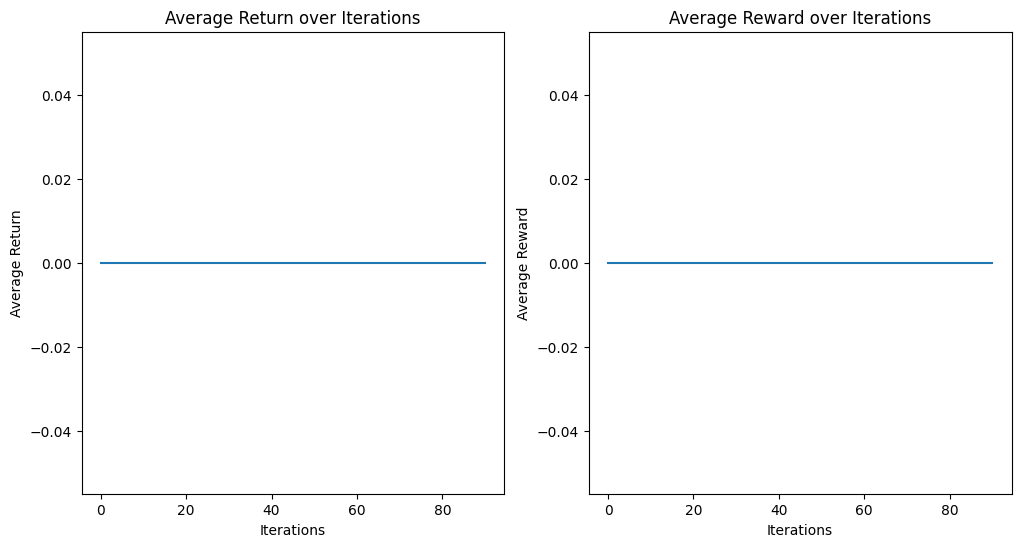

In [108]:
# Evaluate the model
avg_returns = []
avg_rewards = []
for iteration in range(10):  # Evaluate every 10 iterations
    avg_return, avg_reward = evaluate_model(policy, vec_env)
    avg_returns.append(avg_return)
    avg_rewards.append(avg_reward)
    logging.info(f'Iteration {iteration * 10} - Average Return: {avg_return}, Average Reward: {avg_reward}')
    print(f'Iteration {iteration * 10} - Average Return: {avg_return}, Average Reward: {avg_reward}')


# Plot average returns and rewards
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(0, 100, 10), avg_returns)
plt.xlabel('Iterations')
plt.ylabel('Average Return')
plt.title('Average Return over Iterations')

plt.subplot(1, 2, 2)
plt.plot(range(0, 100, 10), avg_rewards)
plt.xlabel('Iterations')
plt.ylabel('Average Reward')
plt.title('Average Reward over Iterations')

plt.show()